<a href="https://colab.research.google.com/github/sacortez-he/Mineria-de-datos-Ev1/blob/main/ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link
https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector

Evaluación de Minería de Datos
- Sección: 004D
- **Fecha de Entrega:** 30-06-2026


### Estudiante 1
- **Nombre: Samuel
- **Apellido: Cortez
- **Correo institucional:sa.cortez@duocuc.cl

----

#Tema del proyecto

El fenómeno que se analiza en este proyecto es el impacto de la adopción de Inteligencia Artificial (IA) en el mercado laboral, considerando cómo tecnologías automatizadas modifican las condiciones de empleo, los salarios, la estabilidad laboral y la necesidad de nuevas competencias en distintos sectores productivos.

El dataset contiene información detallada de más de 300 trabajadores de diversas industrias (IT, salud, educación, finanzas, retail, manufactura, marketing, etc.).
-----

#Descripcion del proyecto
En los últimos años, la adopción de tecnologías de Inteligencia Artificial (IA) ha crecido de manera acelerada en múltiples industrias. Este avance ha generado transformaciones profundas en la forma en que las organizaciones operan y en cómo los trabajadores desempeñan sus funciones. La automatización, el análisis avanzado de datos y los sistemas inteligentes están modificando tareas, reemplazando roles tradicionales y creando nuevas exigencias de habilidades.

-----
## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM**, utilizada ampliamente para abordar proyectos de mineria de datos. Se compone de seis fases fundamentales:


#Comprension del Negocio

En el siguiente dataset se analizara el impacto de la IA en los distntos trabajos, algunas de las columnas que se pueden observar son la edad, industria, nivel de manejo de la IA tambien se puede observar el cambio
existe entre el antes y despues de la implementacion de la IA entre las distintas industrias.

Importar las librerias de Pandas y Numpy

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Crear dataframe

In [9]:
df = pd.read_csv("/content/ai_job_impact.csv")

Muestra las primeras 5 filas

Los resultados observados es que las industrias de marketing con 26 años de experiencia tiene un nivel alto de inteligencia artifical, en cambio uno de los maestros con 28 años tiene un nivel medio.

In [10]:
df.head()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


Muestra las ultimas 5 filas

En las ultimas cinco filas se observa que existen 2 personas con un nivel alto de la IA con experiencia laboral mayor a 10 años

In [11]:
df.tail()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31
1999,E2000,23,Other,Master,Marketing,SEO Specialist,0,High,High,Yes,33830,34809,Modified,37,Yes,9,24.40


Muestra las columnas del dataset


In [12]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

Muestra la cantidad de filas y las columnas(filas,columnas)

Existen 2000 filas y 17 columnas en la tablas

In [13]:
df.shape

(2000, 17)

Muestra la cantidad de nulos y los suma

El resultado obtenido es que no existen resultados nulos en las distintas columnas.

In [14]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education_Level,0
Industry,0
Job_Role,0
Years_Experience,0
AI_Adoption_Level,0
Automation_Risk,0
Upskilling_Required,0


Muestra los tipos de datos que tiene las columnas

Se observa los distintos tipo de datos en las columnas los cuales son object,int64 y float64

In [15]:
df.dtypes

,0
Employee_ID,object
Age,int64
Gender,object
Education_Level,object
Industry,object
Job_Role,object
Years_Experience,int64
AI_Adoption_Level,object
Automation_Risk,object
Upskilling_Required,object


Cuenta la cantidad de datos que hay en la columna seleccionada (Frecuencia y categoria)
Se observa que en la columna de edad, la edad 50 tiene una frecuencia alta al tener 72 de total y la que menos es de 28

In [16]:
df['Age'].value_counts()

,count
Age,
50,72
47,68
38,67
33,65
23,64
53,61
34,60
40,59
25,58


### One-Hot Encoding y Matriz de Correlación

Primero, aplicamos One-Hot Encoding a las columnas categóricas para convertirlas en un formato numérico. Luego, calculamos la matriz de correlación para el DataFrame resultante y la visualizamos con un mapa de calor.

In [17]:

categorical_cols = df.select_dtypes(include='object').columns


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame después de One-Hot Encoding (primeras 5 filas):")
display(df_encoded.head())

DataFrame después de One-Hot Encoding (primeras 5 filas):


,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%,Employee_ID_E0002,Employee_ID_E0003,Employee_ID_E0004,...,Job_Role_Teacher,Job_Role_Technician,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Automation_Risk_Low,Automation_Risk_Medium,Upskilling_Required_Yes,Job_Status_Replaced,Job_Status_Unchanged,Remote_Work_Yes
0,50,26,106820,95455,45,5,-10.64,False,False,False,...,False,False,False,False,False,False,True,True,False,False
1,45,19,74131,72013,36,6,19.05,True,False,False,...,False,False,True,False,True,False,True,False,True,True
2,51,28,35311,42290,46,3,17.05,False,True,False,...,False,False,False,True,False,True,True,False,False,True
3,48,24,114478,107820,50,9,-2.47,False,False,True,...,True,False,False,True,False,True,True,False,False,False
4,24,0,33890,40945,52,6,7.03,False,False,False,...,False,False,False,False,False,True,False,False,False,True


El conjunto de datos presenta una estructura sólida y completa, ya que no se encontraron valores nulos en ninguna de las columnas. Esto asegura que todas las variables tanto numéricas como categóricas estén disponibles en su totalidad para el análisis estadístico, la creación de visualizaciones y la aplicación de modelos posteriores. La falta de datos perdidos hace que la interpretación resulte más sencilla, evita la necesidad de imputaciones y permite trabajar con resultados más precisos y confiables.

In [18]:
df.describe().round()

,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,41.0,17.0,73942.0,78429.0,45.0,6.0,10.0
std,11.0,11.0,26056.0,29352.0,6.0,2.0,17.0
min,22.0,0.0,30036.0,24447.0,35.0,3.0,-20.0
25%,32.0,8.0,51666.0,54087.0,40.0,4.0,-5.0
50%,40.0,16.0,74620.0,76820.0,45.0,6.0,10.0
75%,50.0,26.0,95418.0,100730.0,50.0,8.0,25.0
max,59.0,37.0,119976.0,161745.0,54.0,9.0,40.0


Analisis General

No existe al menos un nulo en ninguna columna

In [19]:
df.isnull().any().any()

np.False_

Se revisó la lista de variables categóricas presentes en el conjunto de datos. En total, se identificaron 10 columnas categóricas, las cuales serán utilizadas en el análisis exploratorio y en la generación de visualizaciones posteriores.

In [20]:
ctext = df.select_dtypes(include=['object'])

Cantidad de columnas

Resulta que existen 2000 filas en la tabla

In [21]:
len(ctext)

2000

Ver la lista de columnas numéricas
Existen 7 tablas numericas

In [22]:
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)

7

Grafico de cajas

Se observa que la media de los salarios antes de la IA esta un poco debajo de los 80.000 y el limite es de 120.000

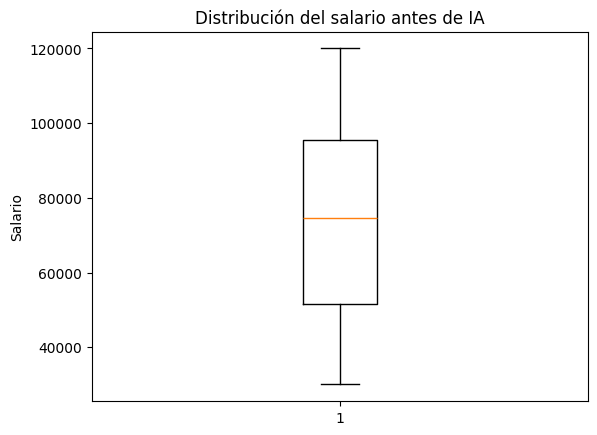

In [23]:
plt.boxplot(df['Salary_Before_AI'])
plt.title('Distribución del salario antes de IA')
plt.ylabel('Salario')
plt.show()

Grafico de cajas

Se observa que la media de los salarios despues de la IA esta un poco debajo de los 80.000 pero ahora el limite es de 160.000

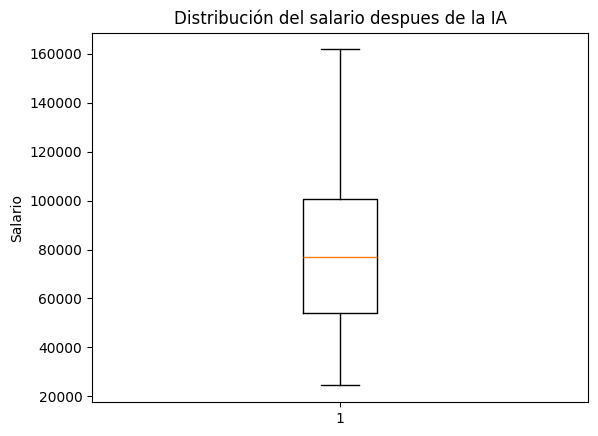

In [24]:
plt.boxplot(df['Salary_After_AI'])
plt.title('Distribución del salario despues de la IA')
plt.ylabel('Salario')
plt.show()

Se definieron los rangos de edad que se utilizarán para la elaboración del gráfico de barras. Las categorías establecidas son las siguientes:
1 = 20–29 años,
2 = 30–39 años,
3 = 40–49 años,
4 = 50–59 años.

In [25]:
rango_edades = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 60],
    labels=['20-29', '30-39', '40-49', '50-59']
)

Se crea el grafico de barras donde la edad que mas tiene personas es la de 30-39 precedida por la de 40-49

/tmp/ipykernel_6294/532136441.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(rango_edades).sort_index().plot(


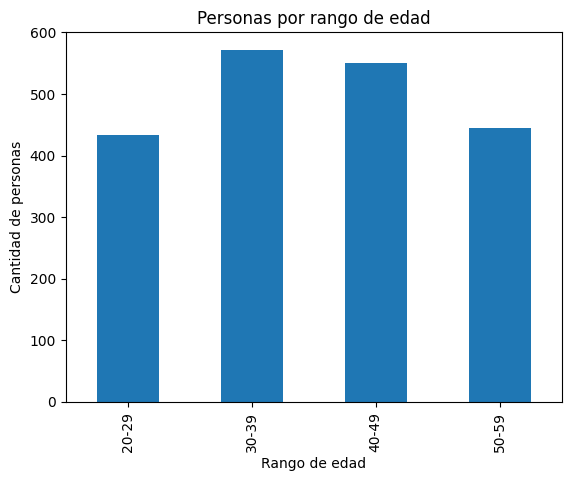

In [26]:
pd.value_counts(rango_edades).sort_index().plot(
    kind='bar',
    title='Personas por rango de edad'
)

plt.xlabel('Rango de edad')
plt.ylabel('Cantidad de personas')
plt.show()

Importar las librerias

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

Se realiza el grafico de correlacion donde los que tienen una alta correlacion son los años de experiencia por edad y salario antes de la IA y salario despues de la IA

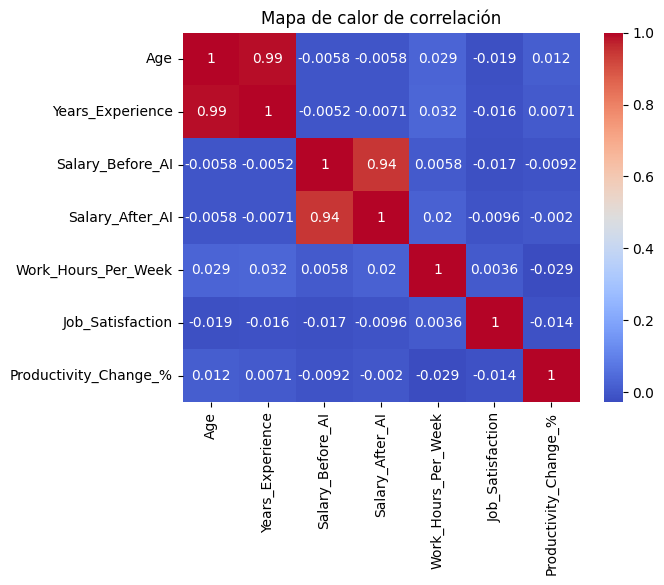

In [28]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlación")
plt.show()

**Regresion Lineal**

In [29]:

X = df_encoded.drop("Salary_After_AI", axis=1)
y = df_encoded["Salary_After_AI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

Datos de Prueba

In [30]:
import pandas as pd

df = pd.DataFrame({
    "Employee_ID": [1, 2, 3, 4, 5],
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Age": [25, 30, 45, 28, 35],
    "Industry": ["Tech", "Finance", "Healthcare", "Education", "Tech"],
    "Salary_Before_AI": [3000, 4500, 6000, 4000, 5000],
    "Salary_After_AI": [3500, 5000, 6500, 4200, 5200],
    "AI_Impact": ["Positive", "Neutral", "Positive", "Negative", "Neutral"],
    "Years_Experience": [2, 5, 15, 4, 10],
    "Education_Level": ["Bachelor", "Master", "PhD", "Bachelor", "Master"]
})

df.to_csv("ai_job_impact_test.csv", index=False)

print(df)


   Employee_ID  Gender  Age    Industry  Salary_Before_AI  Salary_After_AI  \
0            1    Male   25        Tech              3000             3500   
1            2  Female   30     Finance              4500             5000   
2            3    Male   45  Healthcare              6000             6500   
3            4  Female   28   Education              4000             4200   
4            5    Male   35        Tech              5000             5200   

  AI_Impact  Years_Experience Education_Level  
0  Positive                 2        Bachelor  
1   Neutral                 5          Master  
2  Positive                15             PhD  
3  Negative                 4        Bachelor  
4   Neutral                10          Master  


Calculo de las metricas

In [34]:


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


y_pred_lin = lin_reg.predict(X_test)

rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_lin)

print("Regresión Lineal:")
print("RMSE:", rmse)
print("R²:", r2)


Regresión Lineal:
RMSE: 9043.161170607435
R²: 0.8983463598485361


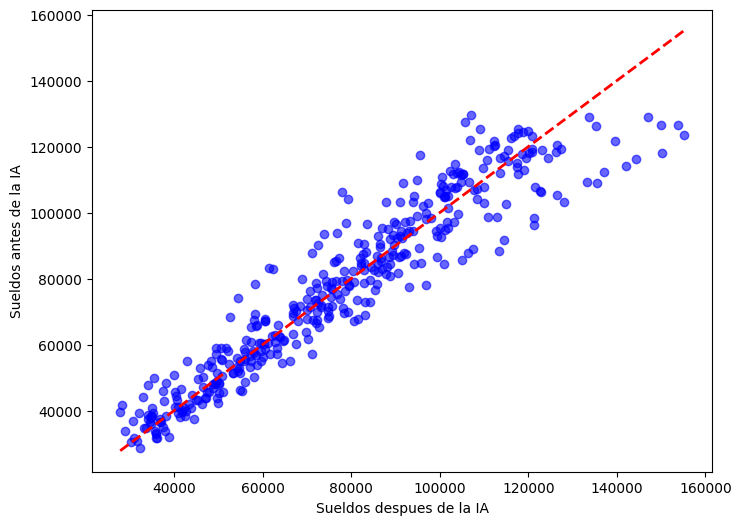

In [ ]:
import matplotlib.pyplot as plt

y_pred_lin = lin_reg.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lin, color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.ylabel("Sueldos antes de la IA")
plt.xlabel("Sueldos despues de la IA")
plt.show()

Al observar el modelo de regresion lineal se puede observar que existe una relacion positiva entre las variables ya que si una de esta sube la otra tambien.Además, la mayoría de los puntos se encuentran cerca de la línea de regresión, muestra que existe una relación clara entre ambas variables.

Modelo K-mens

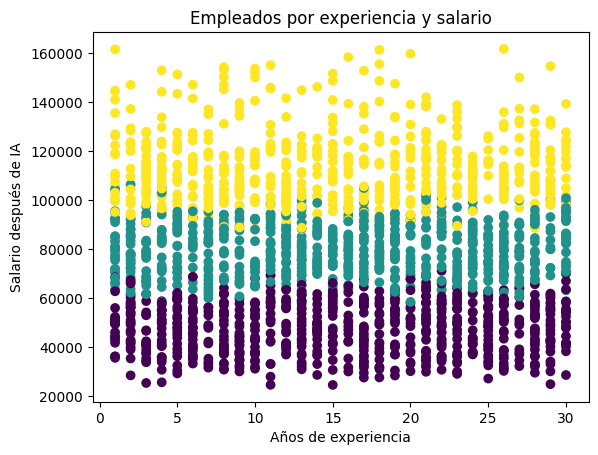

In [ ]:
X = df_encoded[["Salary_Before_AI", "Salary_After_AI", "Years_of_Experience", "Job_Satisfaction"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded["Cluster"] = kmeans.fit_predict(X)

plt.scatter(X["Years_of_Experience"], X["Salary_After_AI"], c=df_encoded["Cluster"], cmap="viridis")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario después de IA")
plt.title("Empleados por experiencia y salario")
plt.show()


Lo que se observa en el gráfico son tres grupos de empleados que se agrupan principalmente por sus años de experiencia, lo que permite distinguir similitudes entre trayectoria laboral y nivel salarial. Sin embargo, también se aprecia que los salarios no dependen directamente de los años de experiencia.

